In [8]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

prepare data

In [9]:
X_numpy,y_numpy=datasets.make_regression(n_samples=100,n_features=1,noise=20,random_state=1)

X=torch.from_numpy(X_numpy.astype(np.float32))

y=torch.from_numpy(y_numpy.astype(np.float32))

y=y.view(y.shape[0],1)

In [10]:
n_samples,n_features=X.shape


input_size=n_features
output_size=1

In [13]:
class LinearRegression(nn.Module):
    def __init__(self,input_dim,output_feature):
        super(LinearRegression,self).__init__()
        self.lin=nn.Linear(input_dim,output_feature)
    
    def forward(self,x):
        return self.lin(x)

In [14]:
model=LinearRegression(input_size,output_size)

In [16]:
criterion=nn.MSELoss()
lr=0.01
optimizer=torch.optim.SGD(model.parameters(),lr=lr)

In [26]:
epochs=100

for epoch in range(epochs):

    y_pred=model(X)

    l=criterion(y_pred,y)

    l.backward()

    optimizer.step()

    optimizer.zero_grad()

    if epoch%10==0:
        print(f"epoch {epoch+1}: ,loss={l.item():.8f}")



epoch 1: ,loss=332.56832886
epoch 11: ,loss=332.56811523
epoch 21: ,loss=332.56799316
epoch 31: ,loss=332.56790161
epoch 41: ,loss=332.56777954
epoch 51: ,loss=332.56774902
epoch 61: ,loss=332.56768799
epoch 71: ,loss=332.56765747
epoch 81: ,loss=332.56765747
epoch 91: ,loss=332.56756592


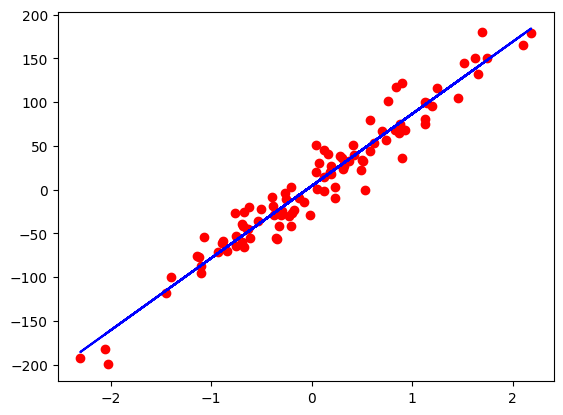

In [28]:
predicted=model(X).detach().numpy()
plt.plot(X_numpy,y_numpy,'ro')
plt.plot(X_numpy,predicted,'b')
plt.show()